In [7]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

BASE = Path("./backlog")

WINDOW_START = 200
WINDOW_END = 250

LOGS = {
    "amax=1": BASE / "gipfel-train-8b-250s-4n-hybrid-35min-amax001-seed41-2324185.log",
    "amax=16": BASE / "gipfel-train-8b-250s-4n-hybrid-35min-amax016-seed41-2324186.log",
    "amax=1024": BASE / "gipfel-train-8b-250s-4n-hybrid-35min-1996684.log",
}

FP8_PEAK_TFLOPS_GPU = 1979.0


In [8]:
log_pattern = re.compile(
    r"iteration\s+(?P<iteration>\d+)/\s*(?P<total_iterations>\d+).*?"
    r"elapsed time per iteration \(ms\):\s+(?P<iter_time_ms>[\d.]+).*?"
    r"throughput per GPU \(TFLOP/s/GPU\):\s+(?P<tflops_per_gpu>[\d.]+).*?"
    r"tokens/sec/GPU:\s+(?P<tokens_sec_gpu>[\d.]+).*?"
    r"lm loss:\s+(?P<lm_loss>[\d.Ee+-]+).*?"
    r"grad norm:\s+(?P<grad_norm>[\d.Ee+-]+).*?"
    r"number of skipped iterations:\s+(?P<skipped_iters>\d+).*?"
    r"number of nan iterations:\s+(?P<nan_iters>\d+)"
)

def parse_log(path: Path, run_name: str) -> pd.DataFrame:
    rows = []

    text = path.read_text(encoding="utf-8", errors="ignore")

    for match in log_pattern.finditer(text):
        rows.append({
            "run": run_name,
            "iteration": int(match.group("iteration")),
            "total_iterations": int(match.group("total_iterations")),
            "iter_time_ms": float(match.group("iter_time_ms")),
            "iter_time_s": float(match.group("iter_time_ms")) / 1000,
            "tflops_per_gpu": float(match.group("tflops_per_gpu")),
            "tokens_sec_gpu": float(match.group("tokens_sec_gpu")),
            "lm_loss": float(match.group("lm_loss")),
            "grad_norm": float(match.group("grad_norm")),
            "skipped_iters": int(match.group("skipped_iters")),
            "nan_iters": int(match.group("nan_iters")),
        })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(f"No rows parsed from {path}")

    df["amax_history_len"] = int(run_name.split("=")[1])
    df["mfu_percent"] = 100 * df["tflops_per_gpu"] / FP8_PEAK_TFLOPS_GPU

    return df


all_runs = []

for run_name, path in LOGS.items():
    if not path.exists():
        print(f"Missing: {path}")
        continue

    df_run = parse_log(path, run_name)
    all_runs.append(df_run)
    print(f"{run_name}: parsed {len(df_run)} iterations from {path.name}")

df = pd.concat(all_runs, ignore_index=True)

display(df.head())
display(df.groupby("run")["iteration"].agg(["min", "max", "count"]))

amax=1: parsed 250 iterations from gipfel-train-8b-250s-4n-hybrid-35min-amax001-seed41-2324185.log
amax=16: parsed 250 iterations from gipfel-train-8b-250s-4n-hybrid-35min-amax016-seed41-2324186.log
amax=1024: parsed 250 iterations from gipfel-train-8b-250s-4n-hybrid-35min-1996684.log


,run,iteration,total_iterations,iter_time_ms,iter_time_s,tflops_per_gpu,tokens_sec_gpu,lm_loss,grad_norm,skipped_iters,nan_iters,amax_history_len,mfu_percent
0,amax=1,1,250,12053.7,12.0537,251.9,5437.0,11.65961,7.763,0,0,1,12.728651
1,amax=1,2,250,8155.4,8.1554,372.3,8036.0,11.65700,11.424,0,0,1,18.812532
2,amax=1,3,250,4234.9,4.2349,717.0,15475.0,10.68603,66.103,0,0,1,36.230419
3,amax=1,4,250,4229.4,4.2294,717.9,15495.0,12.51968,34.910,0,0,1,36.275897
4,amax=1,5,250,4234.1,4.2341,717.2,15478.0,11.60441,242.518,0,0,1,36.240526


,min,max,count
run,,,
amax=1,1,250,250
amax=1024,1,250,250
amax=16,1,250,250


In [9]:
steady = df[
    (df["iteration"] >= WINDOW_START) &
    (df["iteration"] <= WINDOW_END)
].copy()

summary = (
    steady
    .sort_values(["run", "iteration"])
    .groupby("run")
    .agg(
        amax_history_len=("amax_history_len", "first"),
        n_iterations=("iteration", "count"),

        iter_time_s_mean=("iter_time_s", "mean"),
        iter_time_s_std=("iter_time_s", "std"),

        tokens_sec_gpu_mean=("tokens_sec_gpu", "mean"),
        tokens_sec_gpu_std=("tokens_sec_gpu", "std"),

        tflops_gpu_mean=("tflops_per_gpu", "mean"),
        tflops_gpu_std=("tflops_per_gpu", "std"),

        mfu_percent_mean=("mfu_percent", "mean"),
        mfu_percent_std=("mfu_percent", "std"),

        final_loss=("lm_loss", "last"),
        final_grad_norm=("grad_norm", "last"),

        skipped_total=("skipped_iters", "sum"),
        nan_total=("nan_iters", "sum"),
    )
    .sort_values("amax_history_len")
)

if "amax=1024" in summary.index:
    baseline_tokens = summary.loc["amax=1024", "tokens_sec_gpu_mean"]
    summary["speedup_vs_amax1024"] = summary["tokens_sec_gpu_mean"] / baseline_tokens
    summary["time_saved_vs_amax1024_percent"] = (
        1 - baseline_tokens / summary["tokens_sec_gpu_mean"]
    ) * 100

display(summary.round(3))

,amax_history_len,n_iterations,iter_time_s_mean,iter_time_s_std,tokens_sec_gpu_mean,tokens_sec_gpu_std,tflops_gpu_mean,tflops_gpu_std,mfu_percent_mean,mfu_percent_std,final_loss,final_grad_norm,skipped_total,nan_total,speedup_vs_amax1024,time_saved_vs_amax1024_percent
run,,,,,,,,,,,,,,,,
amax=1,1,51,4.254,0.093,15413.725,293.857,714.182,13.620,36.088,0.688,4.911,1.524,0,0,0.992,-0.851
amax=16,16,51,4.293,0.096,15273.627,295.071,707.673,13.665,35.759,0.691,5.013,1.152,0,0,0.983,-1.776
amax=1024,1024,51,4.218,0.094,15544.843,300.099,720.247,13.912,36.394,0.703,4.847,0.887,0,0,1.000,0.000


In [10]:
report_table = summary.copy()

report_table["Tokens/s/GPU"] = (
    report_table["tokens_sec_gpu_mean"].round(1).astype(str)
    + " ± "
    + report_table["tokens_sec_gpu_std"].round(1).astype(str)
)

report_table["TFLOP/s/GPU"] = (
    report_table["tflops_gpu_mean"].round(1).astype(str)
    + " ± "
    + report_table["tflops_gpu_std"].round(1).astype(str)
)

report_table["MFU"] = report_table["mfu_percent_mean"].map(lambda x: f"{x:.1f}%")
report_table["Final Loss"] = report_table["final_loss"].map(lambda x: f"{x:.3f}")
report_table["Final Grad Norm"] = report_table["final_grad_norm"].map(lambda x: f"{x:.3f}")

if "speedup_vs_amax1024" in report_table.columns:
    report_table["Speedup vs. 1024"] = report_table["speedup_vs_amax1024"].map(lambda x: f"{x:.3f}×")
    report_table["Time Saved vs. 1024"] = report_table["time_saved_vs_amax1024_percent"].map(lambda x: f"{x:.1f}%")

cols = [
    "amax_history_len",
    "Tokens/s/GPU",
    "TFLOP/s/GPU",
    "MFU",
    "Final Loss",
    "Final Grad Norm",
    "skipped_total",
    "nan_total",
]

if "Speedup vs. 1024" in report_table.columns:
    cols += ["Speedup vs. 1024", "Time Saved vs. 1024"]

display(
    report_table[cols]
    .rename(columns={
        "amax_history_len": "amax history length",
        "skipped_total": "Skipped iters",
        "nan_total": "NaN iters",
    })
)

,amax history length,Tokens/s/GPU,TFLOP/s/GPU,MFU,Final Loss,Final Grad Norm,Skipped iters,NaN iters,Speedup vs. 1024,Time Saved vs. 1024
run,,,,,,,,,,
amax=1,1,15413.7 ± 293.9,714.2 ± 13.6,36.1%,4.911,1.524,0,0,0.992×,-0.9%
amax=16,16,15273.6 ± 295.1,707.7 ± 13.7,35.8%,5.013,1.152,0,0,0.983×,-1.8%
amax=1024,1024,15544.8 ± 300.1,720.2 ± 13.9,36.4%,4.847,0.887,0,0,1.000×,0.0%


In [11]:
latex_table = (
    report_table[cols]
    .rename(columns={
        "amax_history_len": "Amax history length",
        "skipped_total": "Skipped iters",
        "nan_total": "NaN iters",
    })
    .to_latex(
        index=False,
        escape=False,
        column_format="lrrrrrr",
    )
)

print(latex_table)

\begin{tabular}{lrrrrrr}
\toprule
 Amax history length &     Tokens/s/GPU &   TFLOP/s/GPU &    MFU & Final Loss & Final Grad Norm &  Skipped iters &  NaN iters & Speedup vs. 1024 & Time Saved vs. 1024 \\
                   1 &  15413.7 ± 293.9 &  714.2 ± 13.6 &  36.1% &      4.911 &           1.524 &              0 &          0 &           0.992× &               -0.9% \\
\midrule
                  16 &  15273.6 ± 295.1 &  707.7 ± 13.7 &  35.8% &      5.013 &           1.152 &              0 &          0 &           0.983× &               -1.8% \\
                1024 &  15544.8 ± 300.1 &  720.2 ± 13.9 &  36.4% &      4.847 &           0.887 &              0 &          0 &           1.000× &                0.0% \\
\bottomrule
\end{tabular}



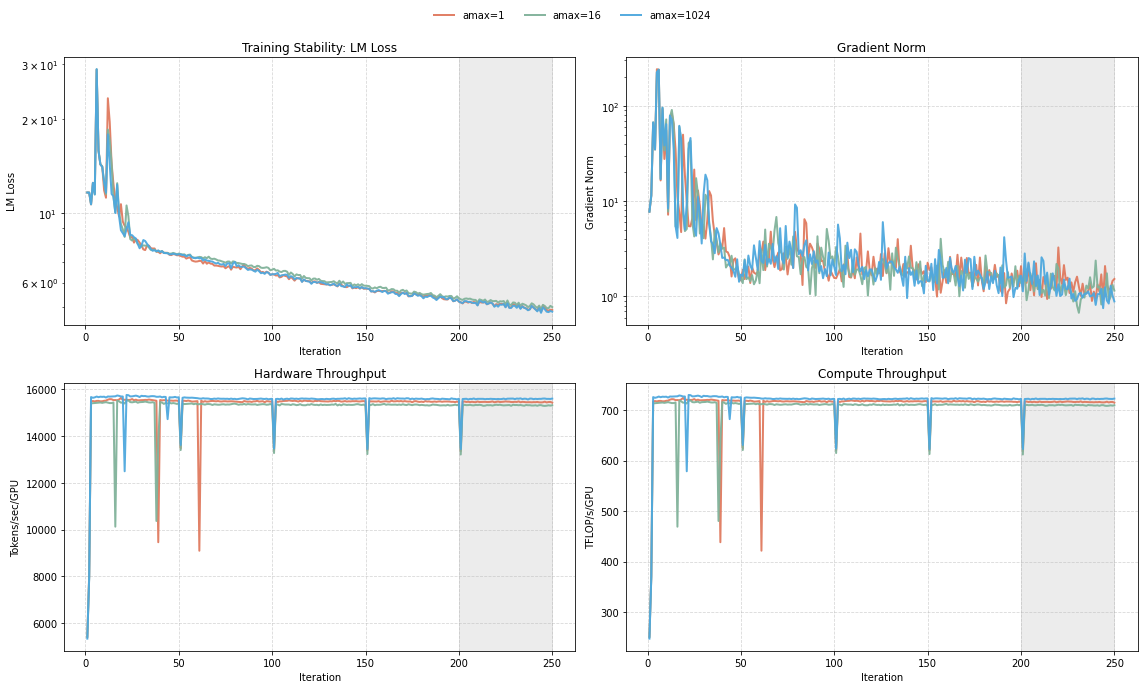

In [12]:
colors = {
    "amax=1": "#E07A5F",
    "amax=16": "#81B29A",
    "amax=1024": "#4EA8DE",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plots = [
    ("lm_loss", "Training Stability: LM Loss", "LM Loss", True),
    ("grad_norm", "Gradient Norm", "Gradient Norm", True),
    ("tokens_sec_gpu", "Hardware Throughput", "Tokens/sec/GPU", False),
    ("tflops_per_gpu", "Compute Throughput", "TFLOP/s/GPU", False),
]

for ax, (col, title, ylabel, log_scale) in zip(axes.flatten(), plots):
    for run_name in sorted(df["run"].unique(), key=lambda x: int(x.split("=")[1])):
        subset = df[df["run"] == run_name]

        ax.plot(
            subset["iteration"],
            subset[col],
            label=run_name,
            color=colors.get(run_name),
            linewidth=2,
            alpha=0.95,
        )

    ax.axvspan(WINDOW_START, WINDOW_END, color="gray", alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.5)

    if log_scale:
        ax.set_yscale("log")

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 0.96),
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

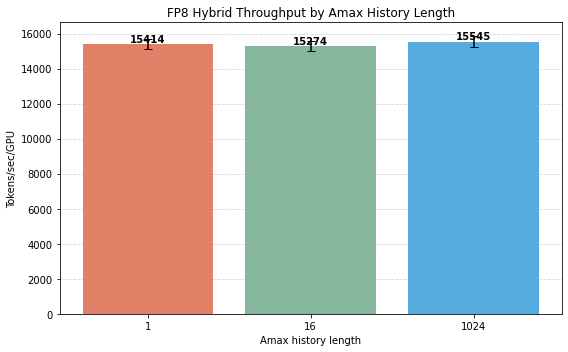

In [13]:
bar_df = summary.sort_values("amax_history_len").copy()

fig, ax = plt.subplots(figsize=(8, 5))

x_labels = [str(v) for v in bar_df["amax_history_len"]]
values = bar_df["tokens_sec_gpu_mean"]
errors = bar_df["tokens_sec_gpu_std"]

bars = ax.bar(
    x_labels,
    values,
    yerr=errors,
    capsize=4,
    color=[colors.get(idx) for idx in bar_df.index],
    alpha=0.95,
)

ax.set_title("FP8 Hybrid Throughput by Amax History Length")
ax.set_xlabel("Amax history length")
ax.set_ylabel("Tokens/sec/GPU")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.0f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()